# Count each

### Load

In [1]:
from pathlib import Path
import json
import re

RESULTS_DIR = Path("all_results")
ARXIV_ID_PATTERN = re.compile(r'^\d{4}\.\d{4,5}(v\d+)?$')

arxiv_paths: dict[str, list[str]] = {}
hf_paths: dict[str, list[str]] = {}
unknown_keys: list[str] = []

for json_path in RESULTS_DIR.glob('*.json'):
    key = json_path.stem
    with json_path.open() as handle:
        payload = json.load(handle)

    path_value = None
    for value in payload.values():
        if isinstance(value, dict) and 'path' in value:
            path_value = value['path']
            break

    if path_value is None:
        continue

    if ARXIV_ID_PATTERN.fullmatch(key):
        arxiv_paths[key] = path_value
    elif any(char.isalpha() for char in key):
        hf_paths[key] = path_value
    else:
        unknown_keys.append(key)

print(f'Loaded {len(arxiv_paths)} arXiv paths and {len(hf_paths)} HF model paths.')
if unknown_keys:
    print(f'WARNING: {len(unknown_keys)} filenames were not classified: {unknown_keys[:5]}')
if len(arxiv_paths) != len(hf_paths):
    print('Counts differ between arXiv and HF entries')
else:
    print('Counts are equal')


Loaded 1070 arXiv paths and 1074 HF model paths.
Counts differ between arXiv and HF entries


The other ones seem to be "philosophical/theoretical foundations of artificial intelligence"
this is of lenght 64, but when gtp predicts it it raises an error saying

!! BAD REQUEST ERROR!!
Error code: 400 - {'error': {'message': "Invalid 'response_format.json_schema.name': string too long. Expected a string with maximum length 64, but got a string with length 70 instead.", 'type': 'invalid_request_error', 'param': 'response_format.json_schema.name', 'code': 'string_above_max_length'}}
skipping paper and filling zeros in score
key: 2208.14037

### collect

In [2]:
from metadata_schemas.acm_ccs import CCS_HIERARCHY

ccs_strings = str(CCS_HIERARCHY).split("'")[1::2]
ccs_counts_hf = {s:0 for s in ccs_strings}
ccs_counts_ax = ccs_counts_hf.copy()

In [3]:
for key in hf_paths:
    for term in hf_paths[key]:
        try:
            ccs_counts_hf[term] += 1
        except KeyError:
            print(key, hf_paths[key])

for key in arxiv_paths:
    for term in arxiv_paths[key]:
        try:
            ccs_counts_ax[term] += 1
        except KeyError:
            print(key, hf_paths[key])


In [4]:
print("Hf\tArxiv\n")
for term in ccs_strings:
    hfc, axc = ccs_counts_hf[term], ccs_counts_ax[term]
    if hfc+axc>5:
        if min(hfc, axc) / max(hfc, axc) < 0.5:
            if axc < hfc:
                print(hfc, "\t", axc, "\t",term)

print("")
for term in ccs_strings:
    hfc, axc = ccs_counts_hf[term], ccs_counts_ax[term]
    if hfc+axc>5:
        if min(hfc, axc) / max(hfc, axc) < 0.5:
            if hfc < axc:
                print(hfc, "\t", axc, "\t",term)

Hf	Arxiv

448 	 169 	 Natural language processing
31 	 13 	 Machine translation
168 	 49 	 Natural language generation
45 	 3 	 Speech recognition
28 	 9 	 Lexical semantics
66 	 14 	 Language resources
19 	 1 	 Description logics
9 	 4 	 Logic programming and answer set programming
67 	 16 	 Reinforcement learning
32 	 10 	 Sequential decision making
13 	 6 	 Inverse reinforcement learning
14 	 0 	 Multi-agent reinforcement learning
9 	 1 	 Learning from demonstrations
9 	 2 	 Semi-supervised learning settings
5 	 1 	 Bayesian network models
36 	 5 	 Regularization

0 	 10 	 Probabilistic reasoning
3 	 13 	 Causal reasoning and diagnostics
1 	 28 	 Planning and scheduling
1 	 12 	 Planning with abstraction and generalization
9 	 25 	 Search methodologies
2 	 12 	 Heuristic function construction
13 	 28 	 Computational control theory
49 	 330 	 Computer vision
5 	 20 	 Image and video acquisition
0 	 6 	 Motion capture
3 	 7 	 Active vision
28 	 154 	 Computer vision representations
2 

# Find time stamps

In [5]:
from dataset_loader import Arxiv_HF_datasets
ahd = Arxiv_HF_datasets()
ahd.prepare()
hf_df, arx_df = ahd.sample_subsets(25)

/home/sondre/profile/llmdap/profiler/dataset_loader.py:448: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  self.arx = self.arx[self.arx["bin"]>=bin_range[0]][self.arx["bin"]<=bin_range[1]]


In [54]:
hf_df = hf_df.set_index("modelId")

In [58]:
from matplotlib import pyplot as plt

In [70]:
def plot_term(term):
    axdates = []
    for key in arxiv_paths:
        if term in arxiv_paths[key]:
            axdates.append(arx_df.loc[key,"submission_date"])
    hfdates = []
    for key in hf_paths:
        if term in hf_paths[key]:
            try:
                hfdates.append(hf_df.loc[key.replace("__", "/",1),"createdAt"])
            except KeyError:
                print("KeyError:", key)
    if len(axdates)+len(hfdates)<10:
        return
    plt.hist(axdates, bins=25, label="arx")
    plt.hist(hfdates, bins=25, alpha=0.6, label="HF")
    plt.title(term)
    plt.legend()
    plt.show()

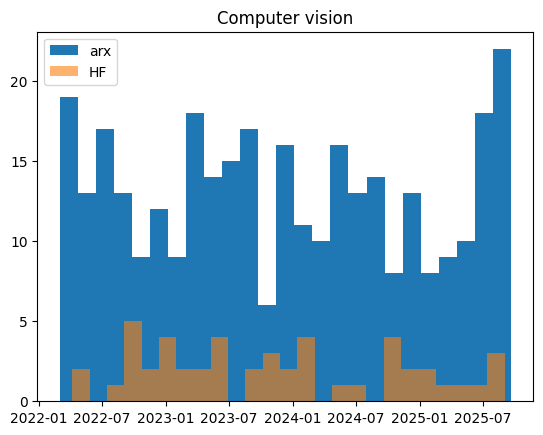

In [71]:
plot_term(term = "Computer vision")

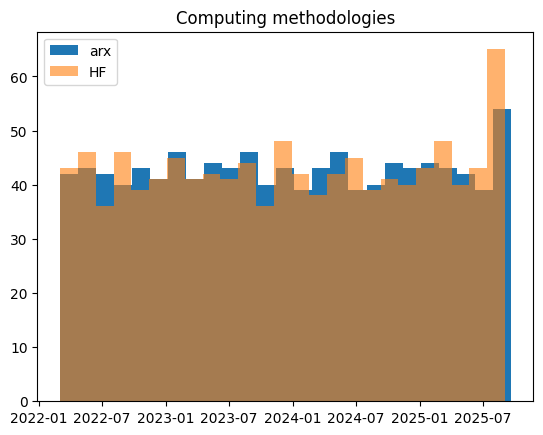

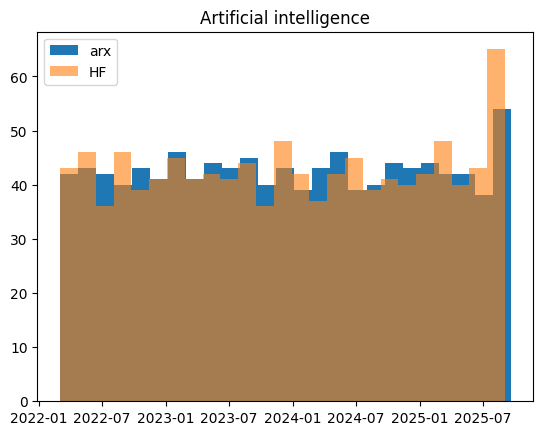

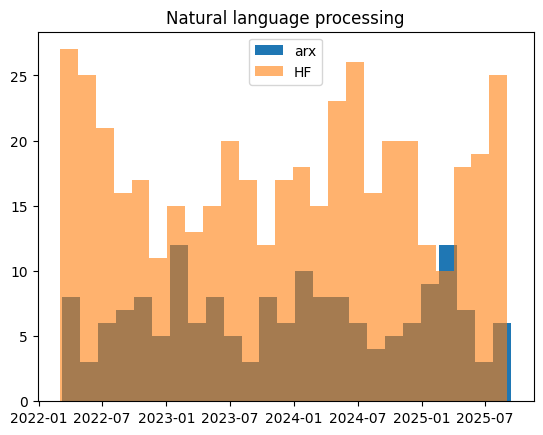

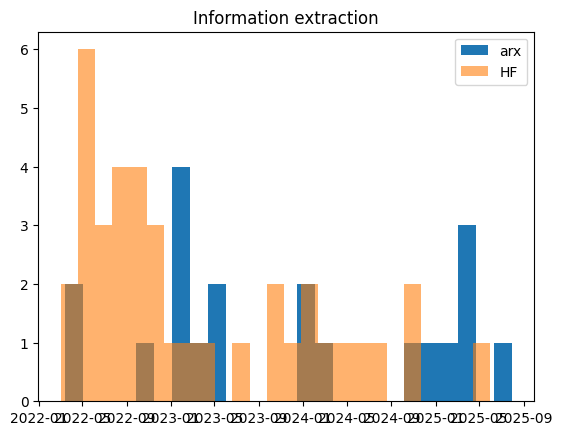

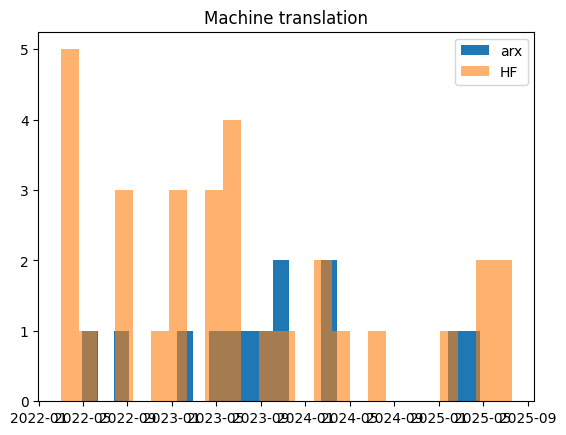

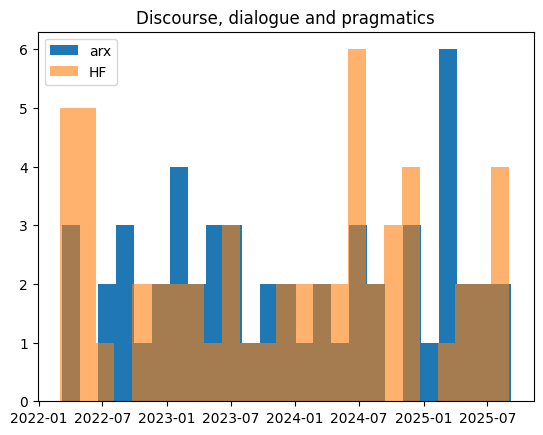

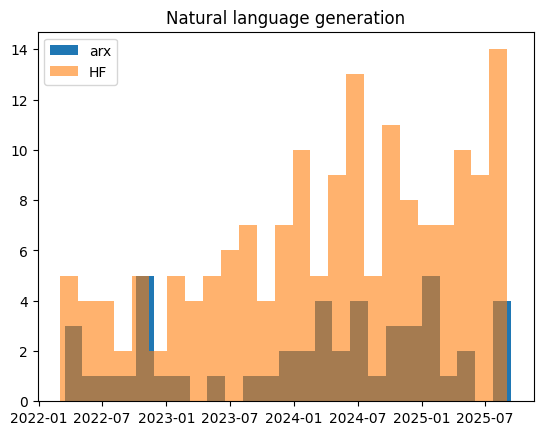

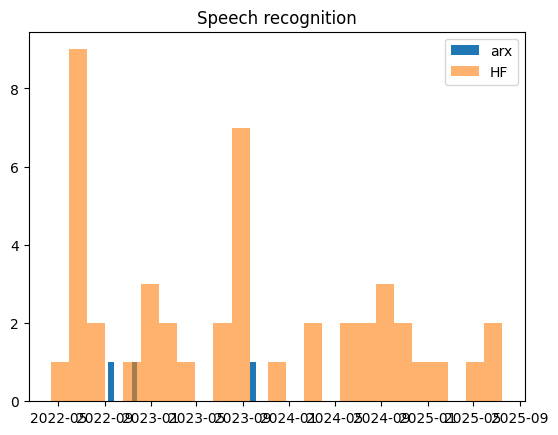

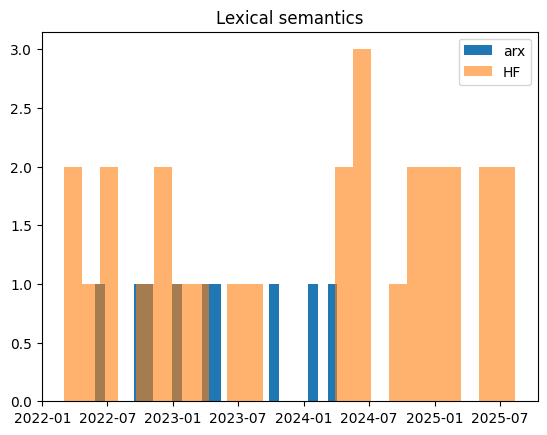

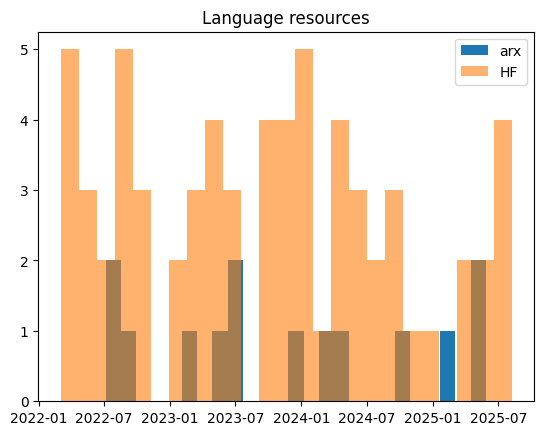

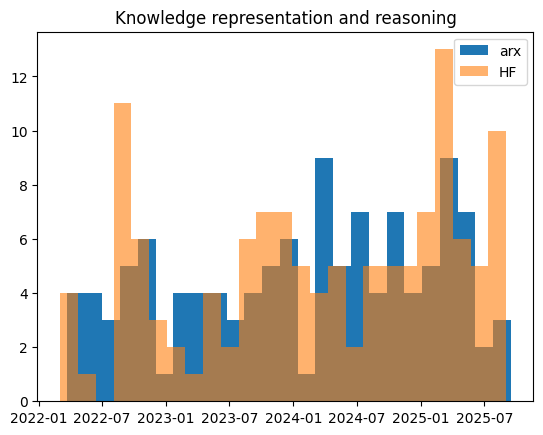

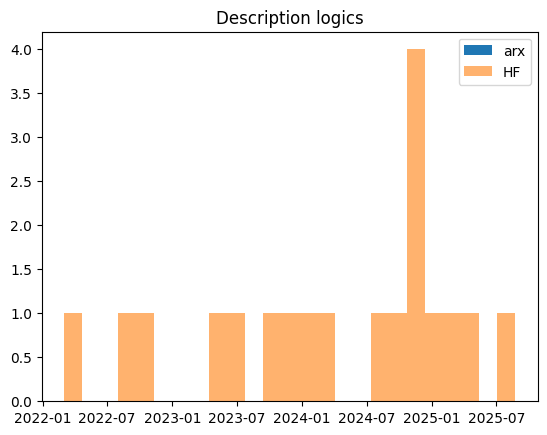

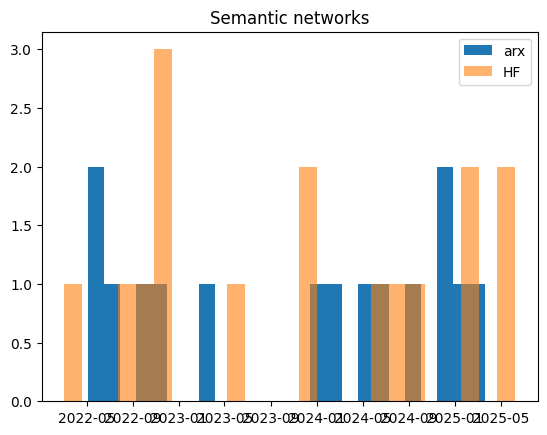

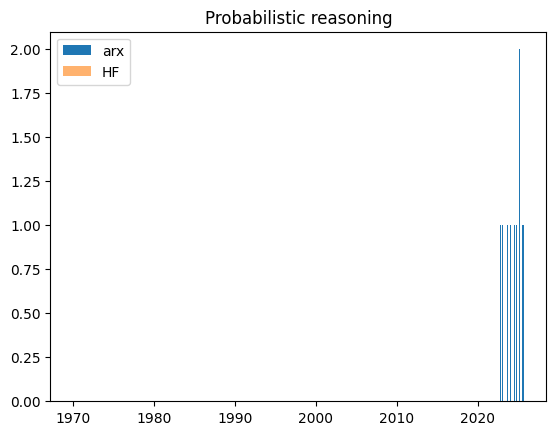

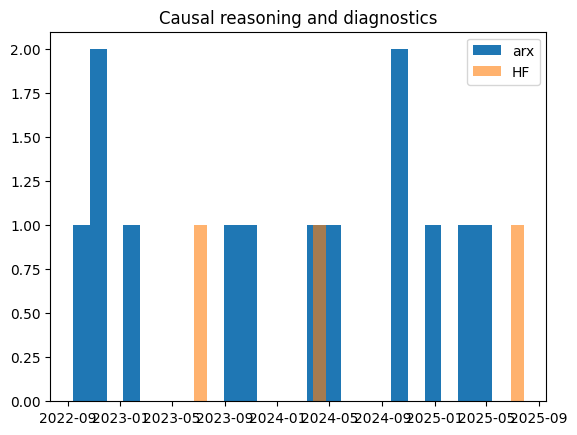

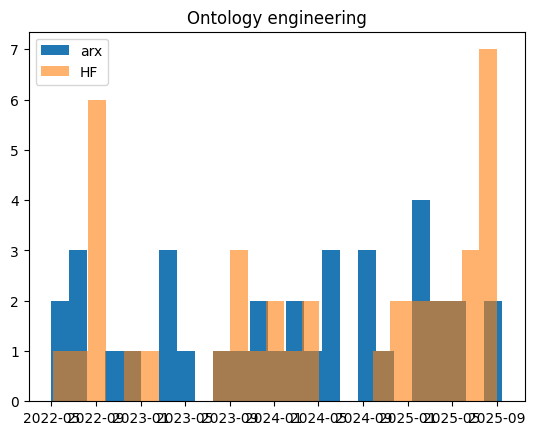

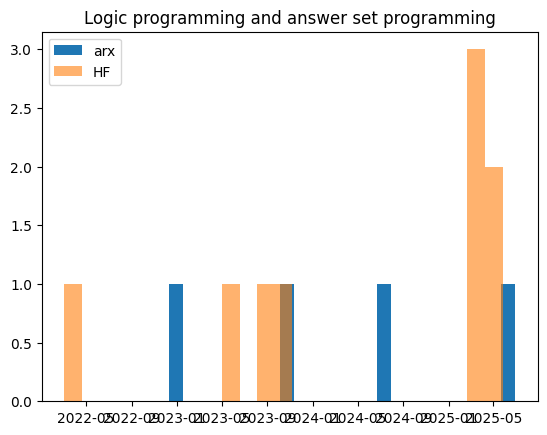

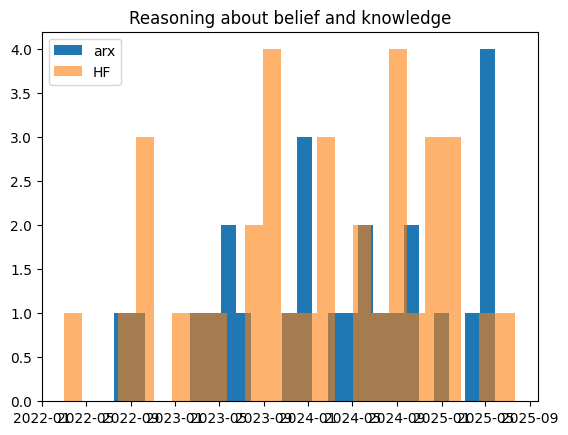

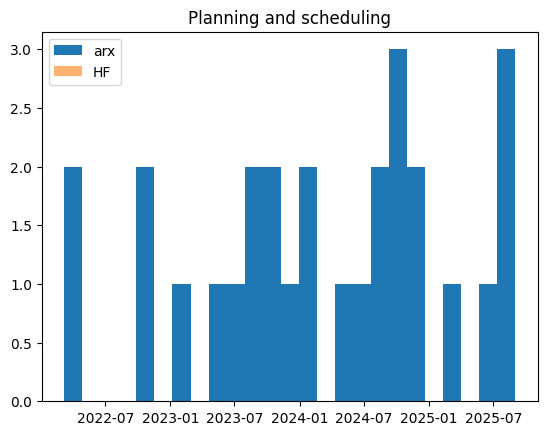

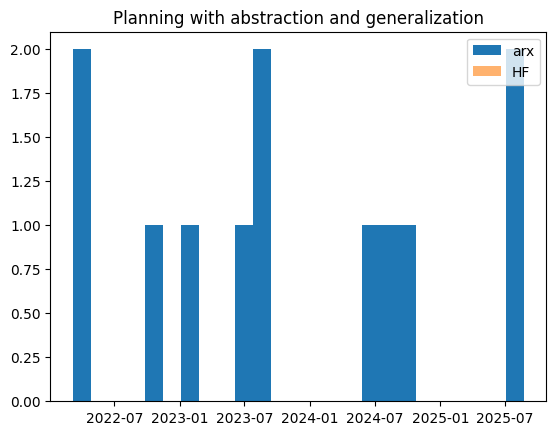

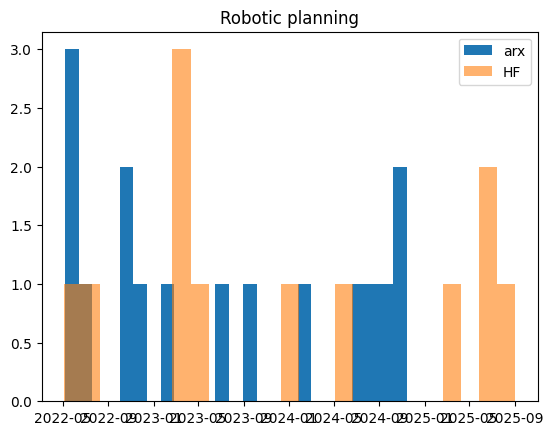

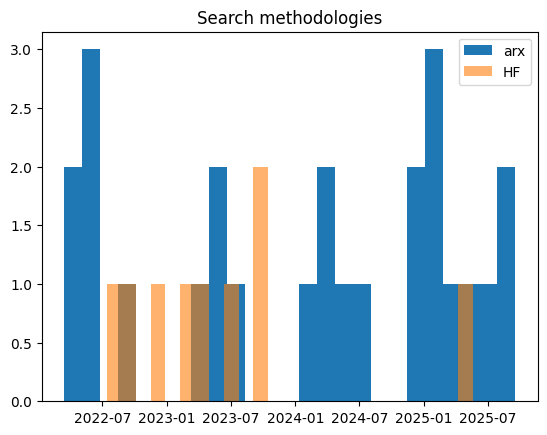

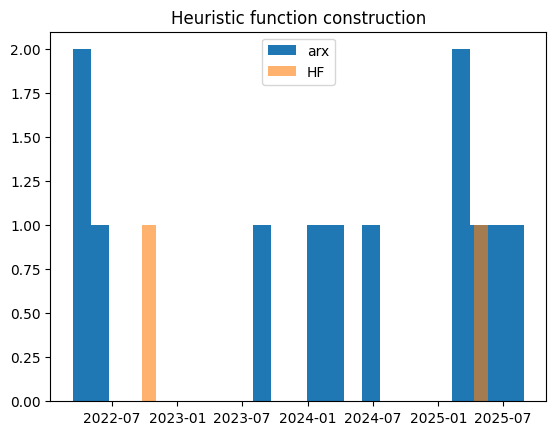

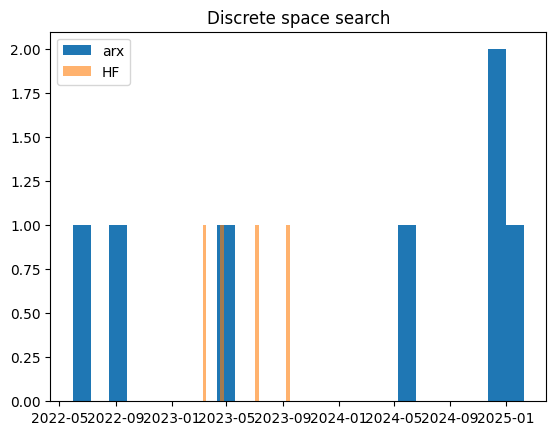

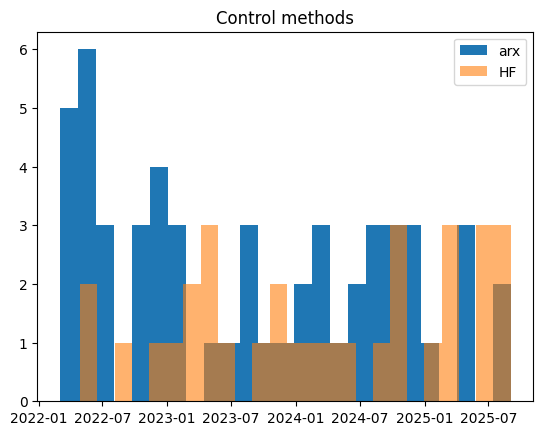

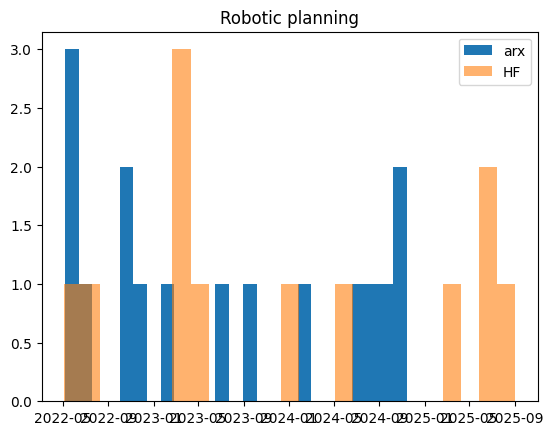

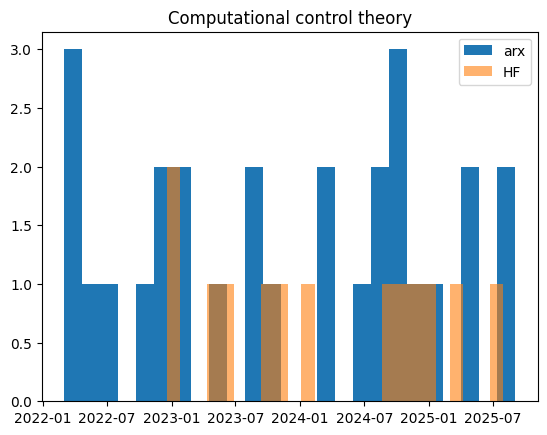

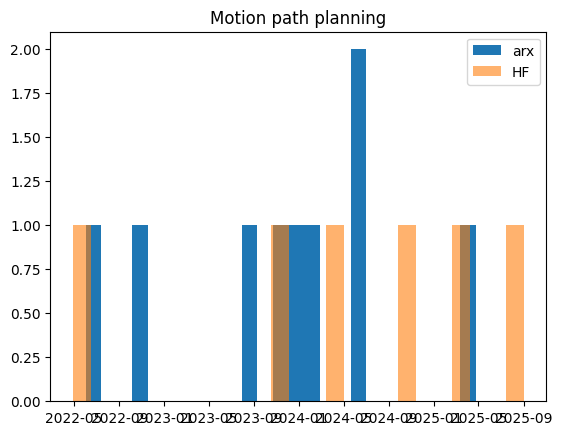

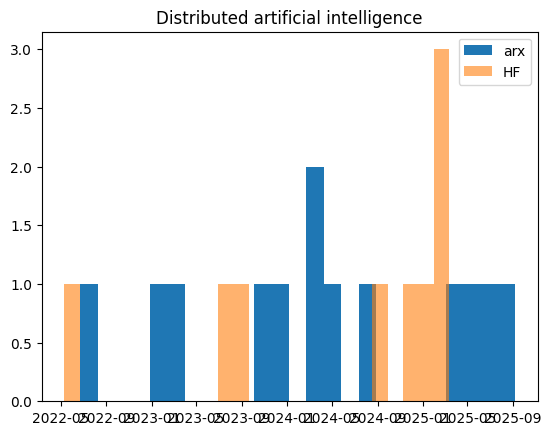

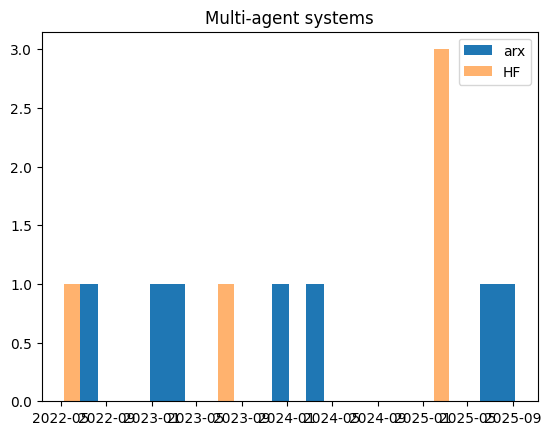

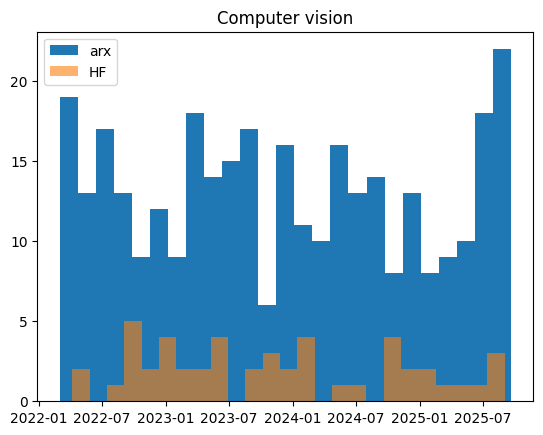

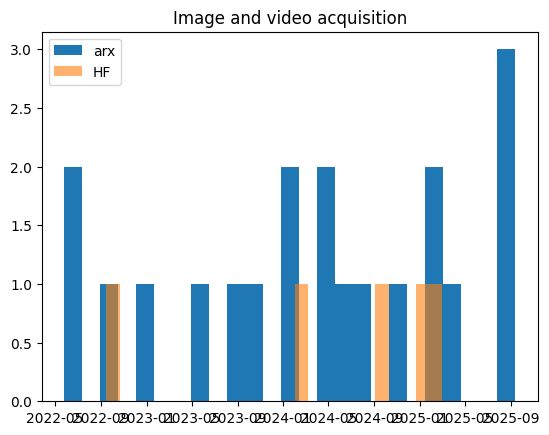

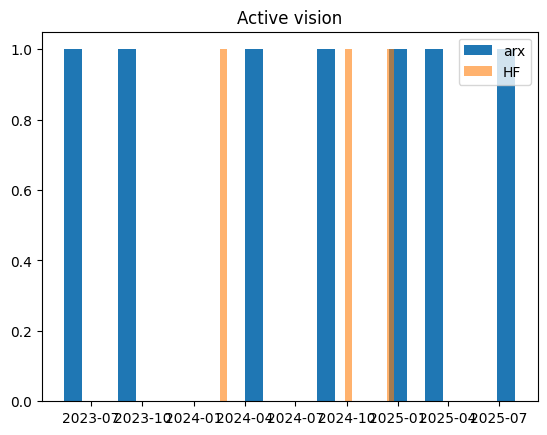

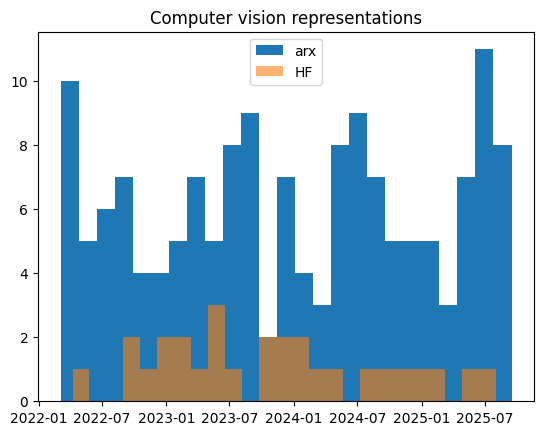

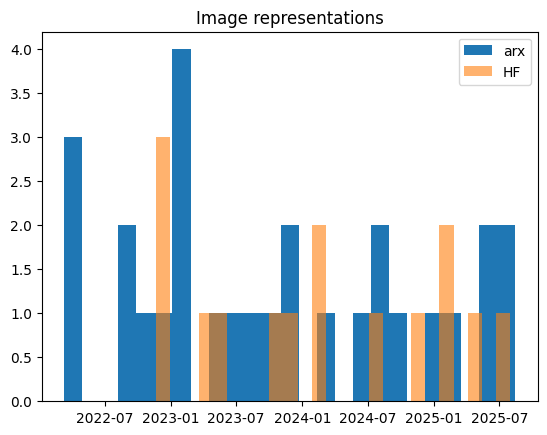

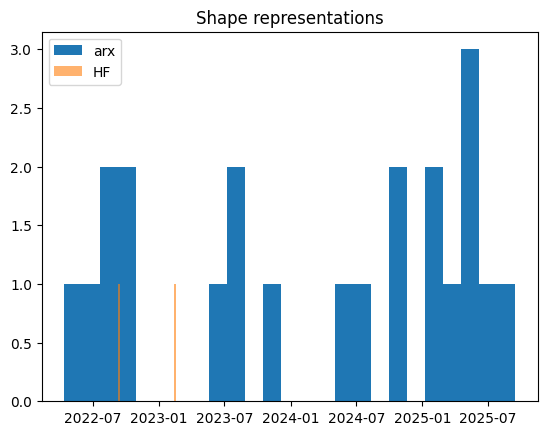

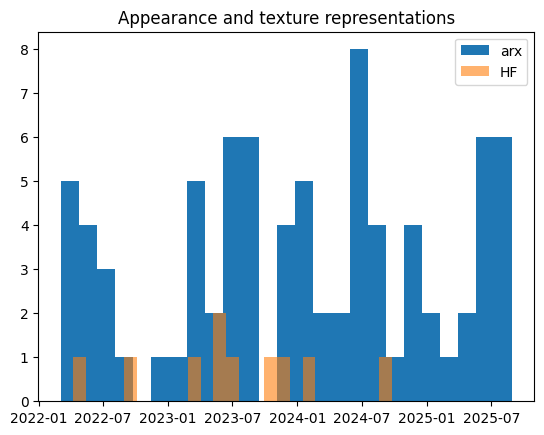

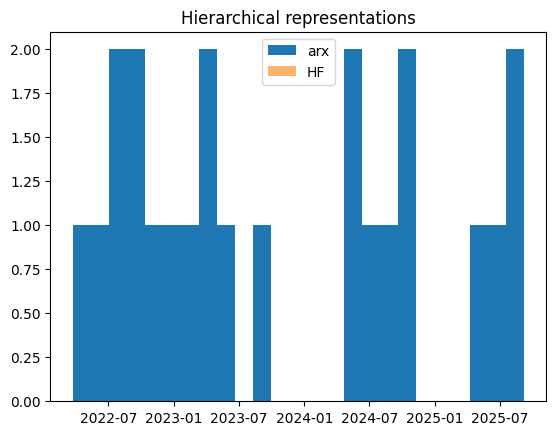

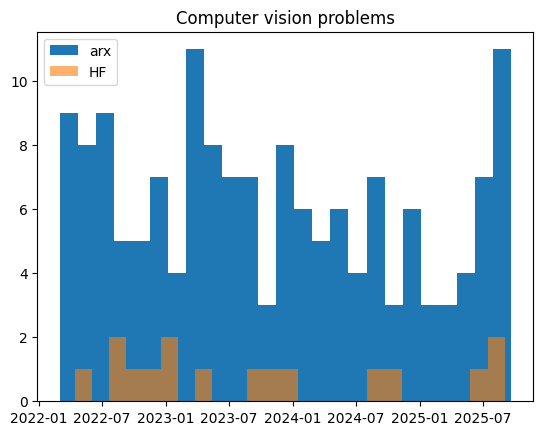

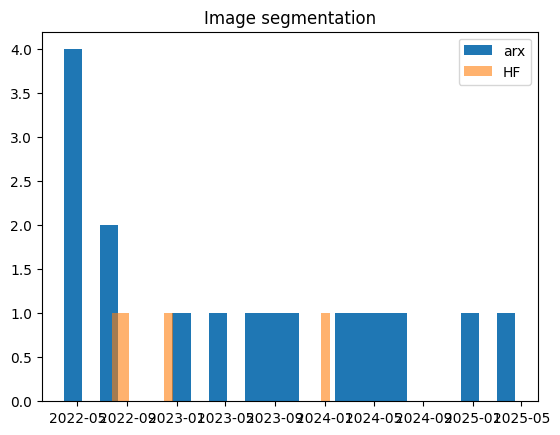

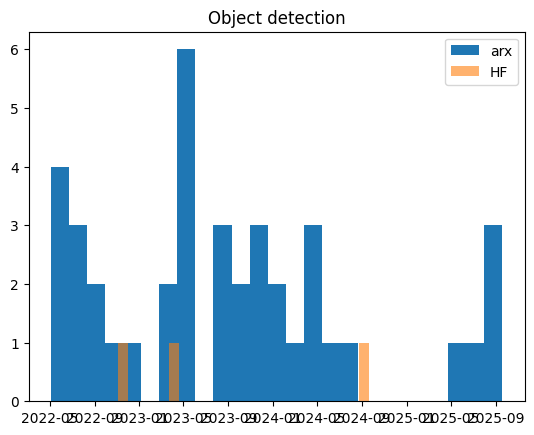

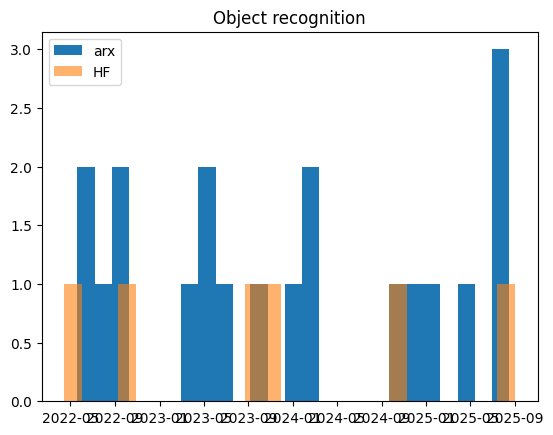

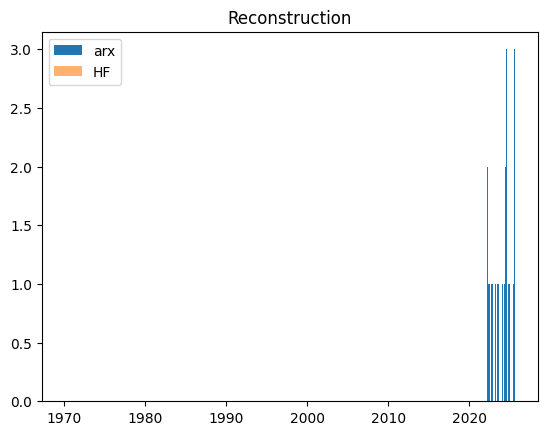

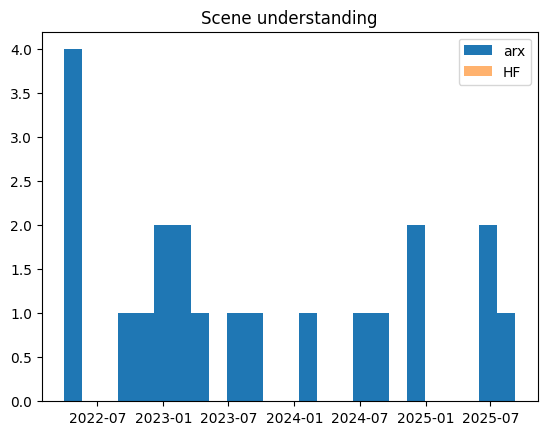

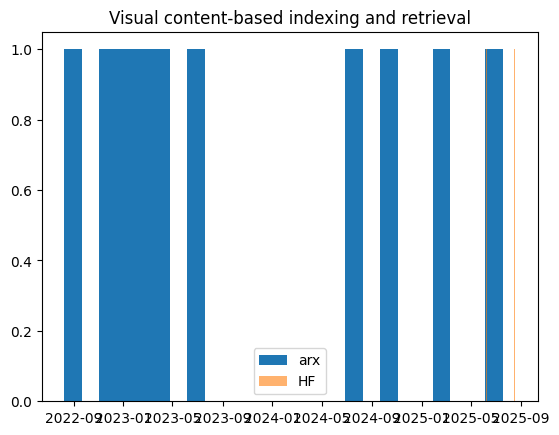

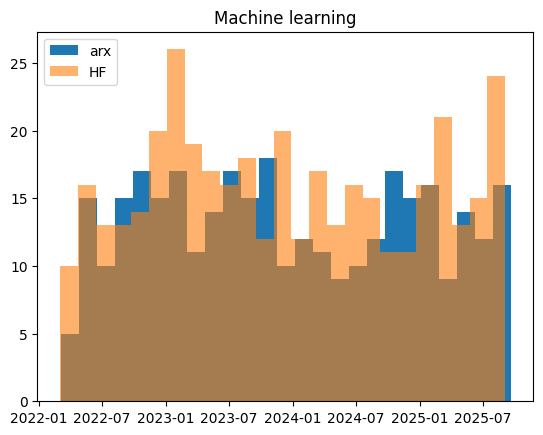

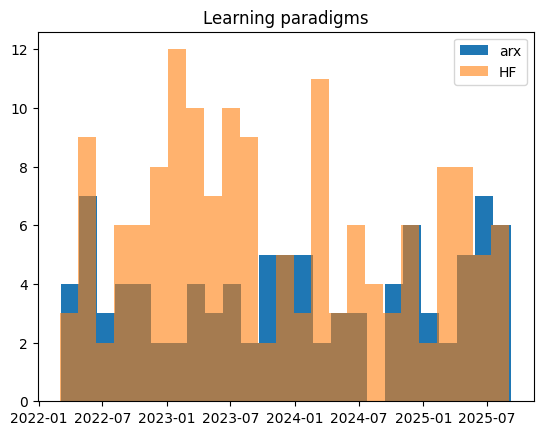

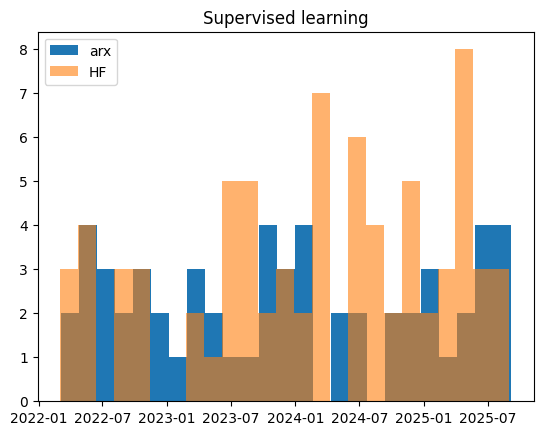

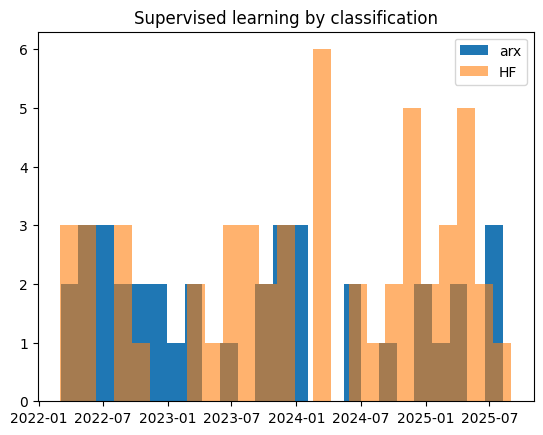

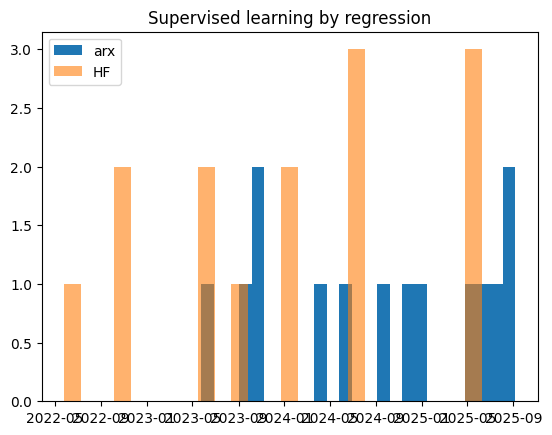

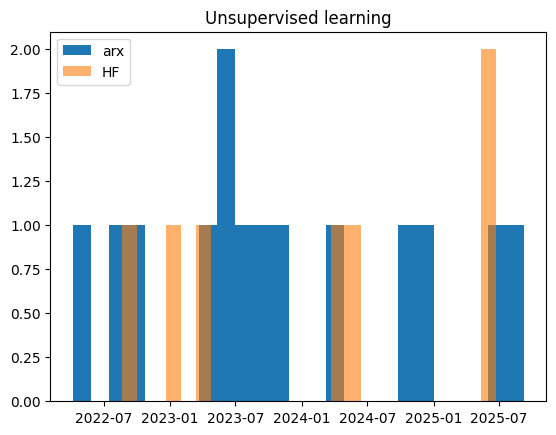

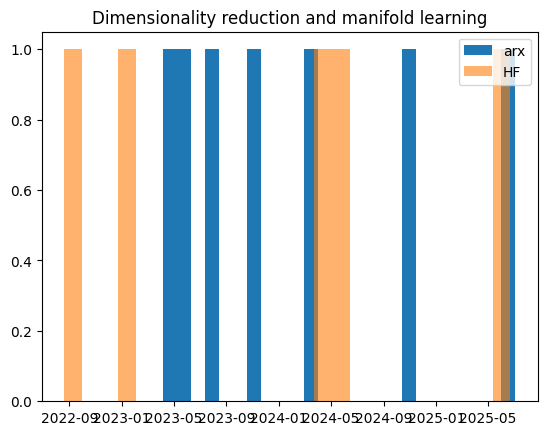

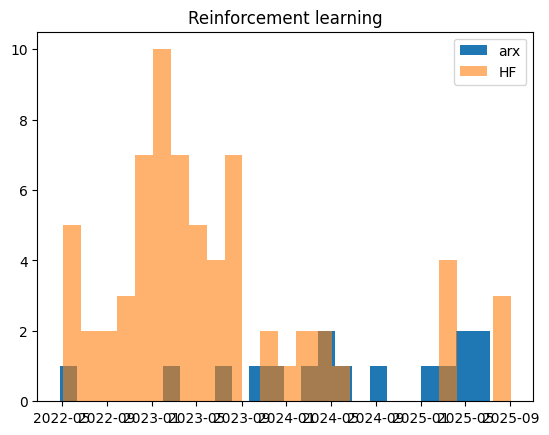

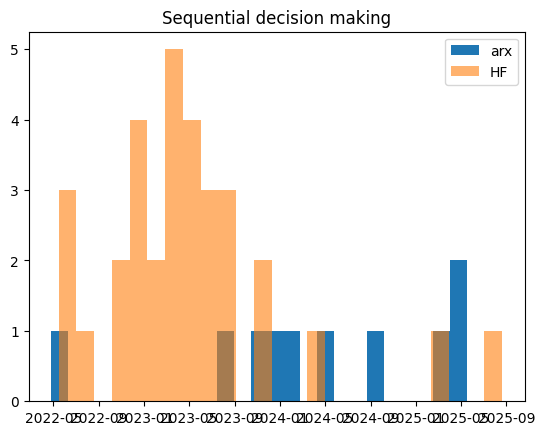

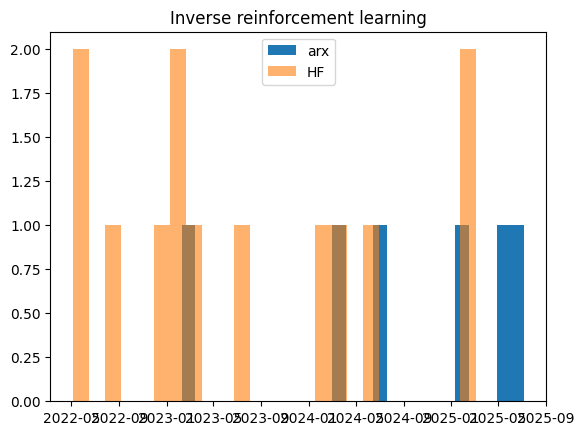

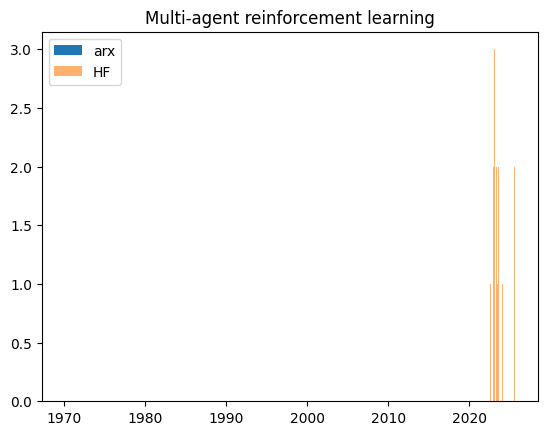

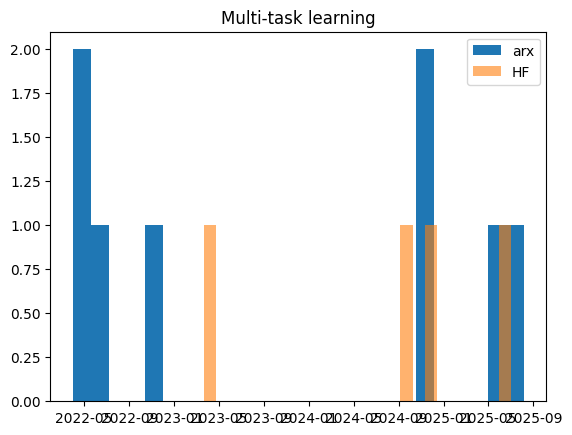

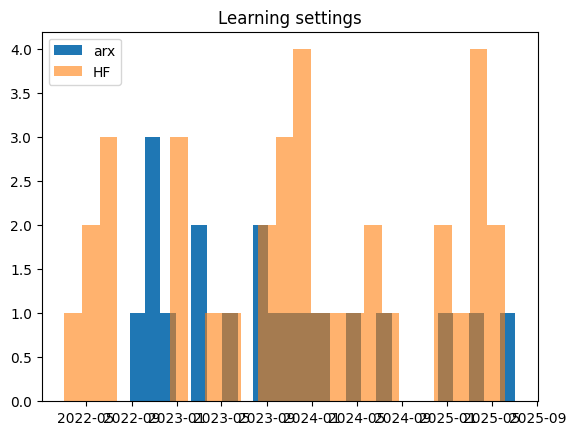

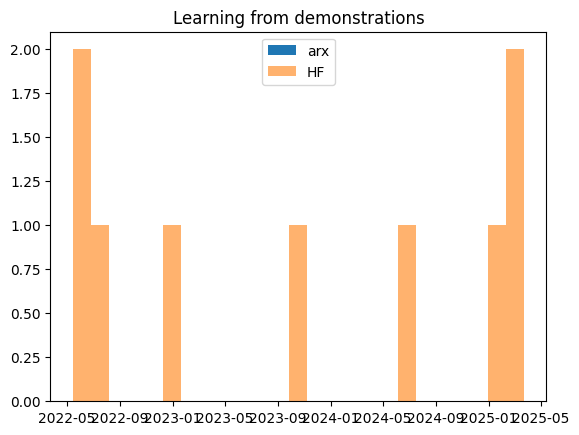

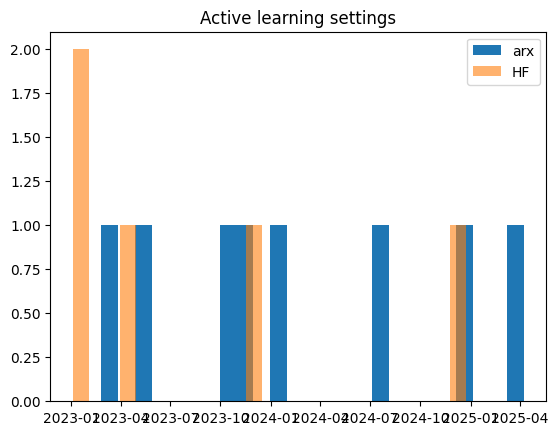

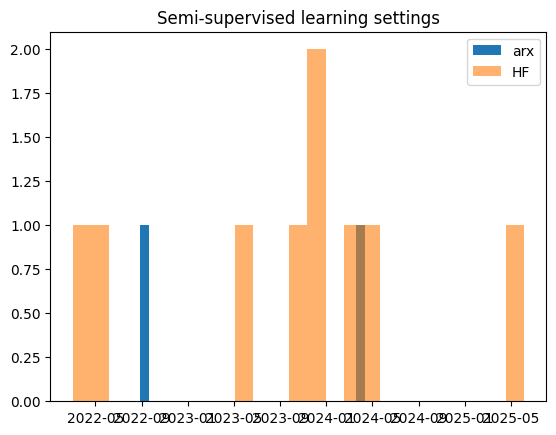

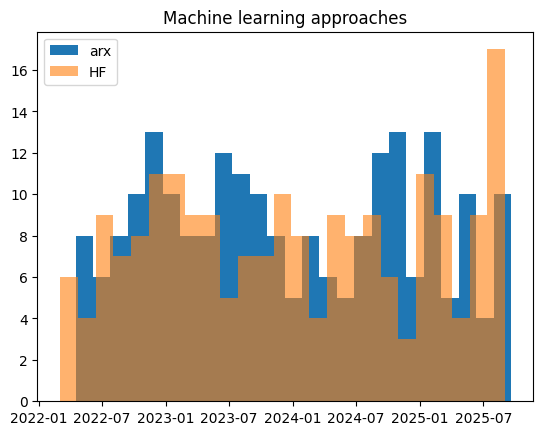

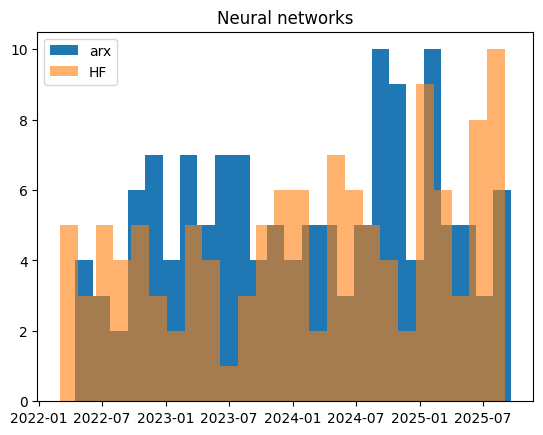

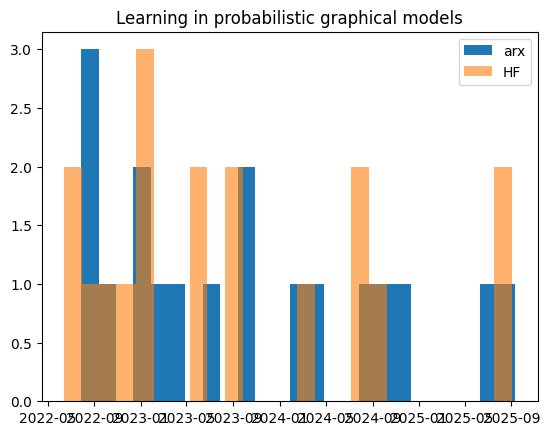

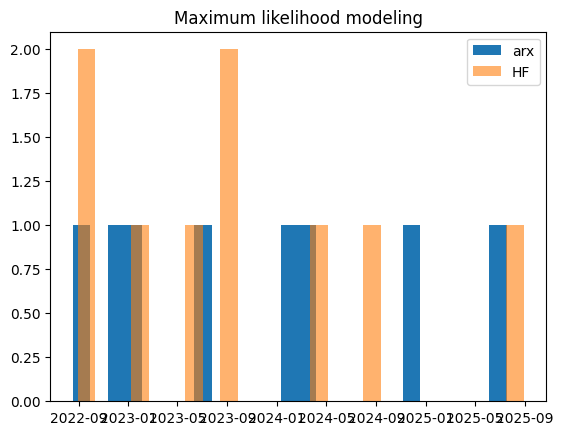

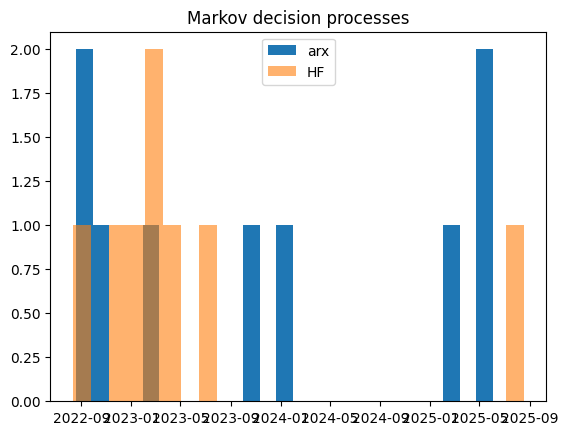

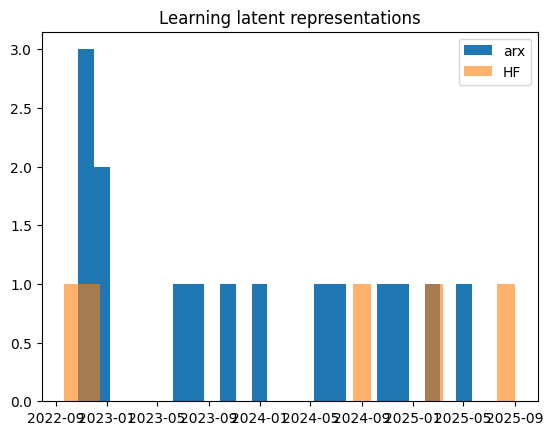

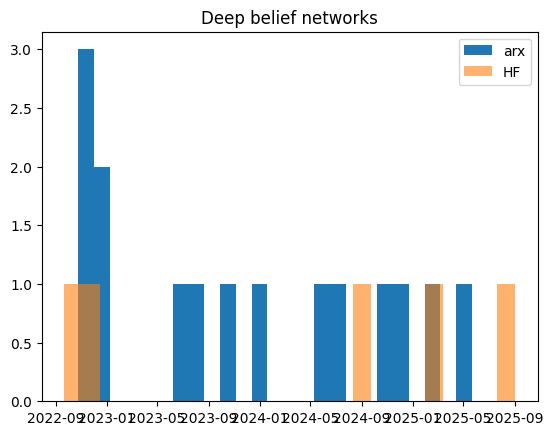

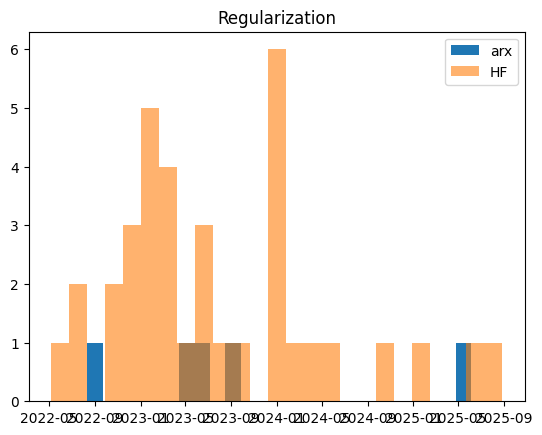

In [72]:
for term in ccs_strings:
    plot_term(term)
